# AWS Spot Pricing Analysis and ROI Forecast for ML/AI Workloads

This project analyzes historical AWS Spot Instance prices for 'r3.xlarge' Linux/UNIX to estimate potential ROI compared to On-Demand pricing.
Using time series decomposition, ARIMA, and Prophet models, it forecasts future prices to support cost-efficient planning of ML/AI workloads.

Columns:

- **datetime**: Timestamp of the Spot price. Format: YYYY-MM-DD HH:MM:SS+TZ.

- **instance_type**: Type of Spot Instance (['SUSE Linux' 'Linux/UNIX' 'Windows'])

- **os**: Operating system of the virtual machine
(Unique values used in the project: 'r3.xlarge')

- **region**: AWS region and Availability Zone eu-west-1 (Ireland)

- **price**: Spot price in USD per hour. Continuous numeric value. (Example: 0.2076 USD/h)

**Import dataset**

In [ ]:
import pandas as pd

df = pd.read_csv("eu-west-1.csv")
df

,2017-05-08 21:46:14+00:00,p2.xlarge,Windows,eu-west-1c,0.2958
0,2017-05-08 21:46:11+00:00,r3.xlarge,SUSE Linux,eu-west-1b,0.1524
1,2017-05-08 21:46:11+00:00,r3.xlarge,Linux/UNIX,eu-west-1b,0.0524
2,2017-05-08 21:46:11+00:00,c4.xlarge,SUSE Linux,eu-west-1b,0.1588
3,2017-05-08 21:46:11+00:00,c4.xlarge,Linux/UNIX,eu-west-1b,0.0588
4,2017-05-08 21:46:11+00:00,r4.8xlarge,Windows,eu-west-1b,1.7213
...,...,...,...,...,...
290026,2017-05-04 00:31:34+00:00,m3.xlarge,SUSE Linux,eu-west-1a,0.1650
290027,2017-05-04 00:31:34+00:00,m3.xlarge,Linux/UNIX,eu-west-1a,0.0650
290028,2017-05-04 00:31:33+00:00,i2.xlarge,SUSE Linux,eu-west-1b,0.2728
290029,2017-05-04 00:31:33+00:00,i2.xlarge,Linux/UNIX,eu-west-1b,0.1728


**Data Exploration and pre-processing**

In [ ]:
#shape
df.shape

(290031, 5)

In [ ]:
#info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290031 entries, 0 to 290030
Data columns (total 5 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   2017-05-08 21:46:14+00:00  290031 non-null  object 
 1   p2.xlarge                  290030 non-null  object 
 2   Windows                    290030 non-null  object 
 3   eu-west-1c                 290030 non-null  object 
 4   0.2958                     290030 non-null  float64
dtypes: float64(1), object(4)
memory usage: 11.1+ MB


In [ ]:
#add columns name
df.columns = ['datetime', 'instance_type', 'os', 'region', 'price']
df


,datetime,instance_type,os,region,price
0,2017-05-08 21:46:11+00:00,r3.xlarge,SUSE Linux,eu-west-1b,0.1524
1,2017-05-08 21:46:11+00:00,r3.xlarge,Linux/UNIX,eu-west-1b,0.0524
2,2017-05-08 21:46:11+00:00,c4.xlarge,SUSE Linux,eu-west-1b,0.1588
3,2017-05-08 21:46:11+00:00,c4.xlarge,Linux/UNIX,eu-west-1b,0.0588
4,2017-05-08 21:46:11+00:00,r4.8xlarge,Windows,eu-west-1b,1.7213
...,...,...,...,...,...
290026,2017-05-04 00:31:34+00:00,m3.xlarge,SUSE Linux,eu-west-1a,0.1650
290027,2017-05-04 00:31:34+00:00,m3.xlarge,Linux/UNIX,eu-west-1a,0.0650
290028,2017-05-04 00:31:33+00:00,i2.xlarge,SUSE Linux,eu-west-1b,0.2728
290029,2017-05-04 00:31:33+00:00,i2.xlarge,Linux/UNIX,eu-west-1b,0.1728


In [ ]:
#null values analysis
df.isna().sum()


,0
datetime,0
instance_type,1
os,1
region,1
price,1


In [ ]:
df = df.dropna()

In [ ]:
#datatime pre-processing
df['datetime'] = pd.to_datetime(df['datetime'])
df.dtypes

/tmp/ipython-input-3925142908.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['datetime'] = pd.to_datetime(df['datetime'])


,0
datetime,"datetime64[ns, UTC]"
instance_type,object
os,object
region,object
price,float64


In [ ]:
#Select os Linux/UNIX and 'r3.xlarge' as instance
df_ml = df[(df['os'] == 'Linux/UNIX') & (df['instance_type'] == 'r3.xlarge')]
df_ml.head()

,datetime,instance_type,os,region,price
1,2017-05-08 21:46:11+00:00,r3.xlarge,Linux/UNIX,eu-west-1b,0.0524
111,2017-05-08 21:44:01+00:00,r3.xlarge,Linux/UNIX,eu-west-1c,0.0594
190,2017-05-08 21:42:01+00:00,r3.xlarge,Linux/UNIX,eu-west-1c,0.0593
191,2017-05-08 21:42:01+00:00,r3.xlarge,Linux/UNIX,eu-west-1b,0.0526
238,2017-05-08 21:41:01+00:00,r3.xlarge,Linux/UNIX,eu-west-1c,0.0597


## Time series analysis

In [ ]:
#hours group

# datetime as index
df_hourly = df_ml.set_index('datetime')

# Resample to 1 h: calculate average price for each hour
df_hourly = df_hourly['price'].resample('H').mean()
df_hourly.head()

/tmp/ipython-input-194514261.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df_hourly['price'].resample('H').mean()


,price
datetime,
2017-05-04 00:00:00+00:00,0.054132
2017-05-04 01:00:00+00:00,0.053968
2017-05-04 02:00:00+00:00,0.054908
2017-05-04 03:00:00+00:00,0.054608
2017-05-04 04:00:00+00:00,0.056197


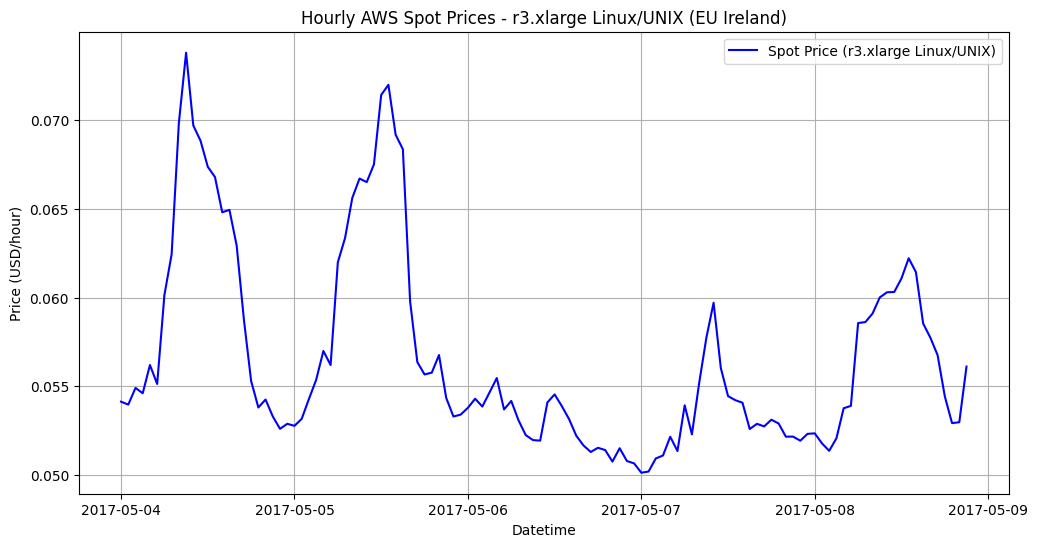

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df_hourly.index, df_hourly.values, color='blue', label='Spot Price (r3.xlarge Linux/UNIX)')
plt.title("Hourly AWS Spot Prices - r3.xlarge Linux/UNIX (EU Ireland)")
plt.xlabel("Datetime")
plt.ylabel("Price (USD/hour)")
plt.grid(True)
plt.legend()
plt.show()


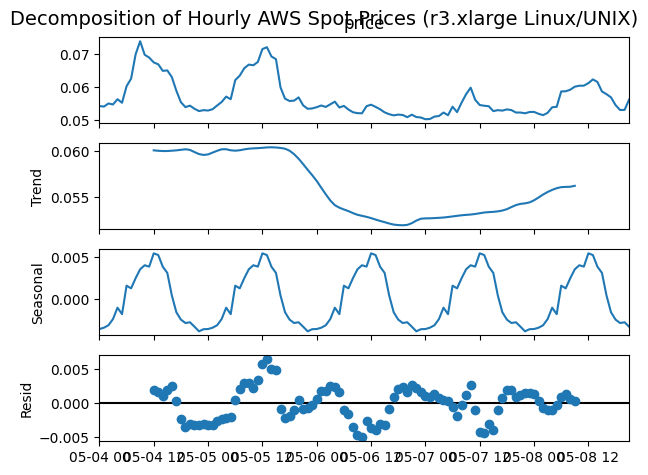

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# decomposition
decomp = seasonal_decompose(df_hourly, model='additive', period=24)  # period=24 ore, ciclo giornaliero

# Plot
decomp.plot()
plt.suptitle("Decomposition of Hourly AWS Spot Prices (r3.xlarge Linux/UNIX)", fontsize=14)
plt.show()


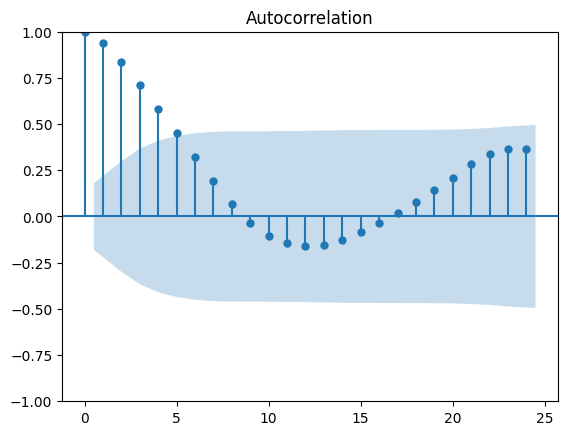

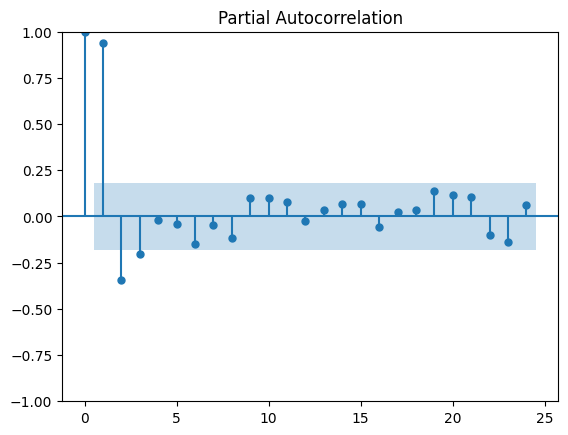

datetime
2017-05-04 00:00:00+00:00    0.054132
2017-05-04 01:00:00+00:00    0.053968
2017-05-04 02:00:00+00:00    0.054908
2017-05-04 03:00:00+00:00    0.054608
2017-05-04 04:00:00+00:00    0.056197
Freq: h, Name: price, dtype: float64


In [ ]:
#ACF E PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# ACF
plot_acf(df_hourly, lags = 24)
plt.show()

# PACF
plot_pacf(df_hourly, lags = 24)
plt.show()

print(df_hourly.head())


In [ ]:
#stationarity test
from statsmodels.tsa.stattools import adfuller

result = adfuller(df_hourly)
print(result[1])

0.01919965854353294


In [ ]:
#arima
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import pandas as pd

# Parametri
p = 6
d = 0
q = 2

# Model
model = ARIMA(df_hourly, order = (p,d,q))
#fit
model_fit = model.fit()

# Summary
print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                  price   No. Observations:                  118
Model:                 ARIMA(6, 0, 2)   Log Likelihood                 579.118
Date:                Mon, 23 Feb 2026   AIC                          -1138.236
Time:                        09:29:53   BIC                          -1110.529
Sample:                    05-04-2017   HQIC                         -1126.986
                         - 05-08-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0566      0.002     30.084      0.000       0.053       0.060
ar.L1          0.7361      0.773      0.953      0.341      -0.778       2.250
ar.L2          0.2197      0.877      0.251      0.8

**Prophet**

/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


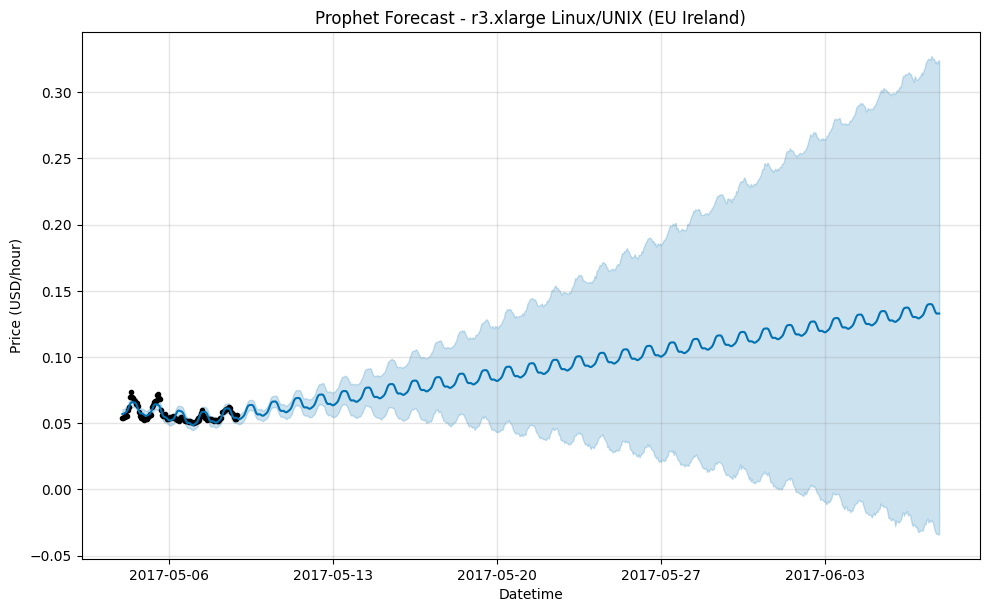

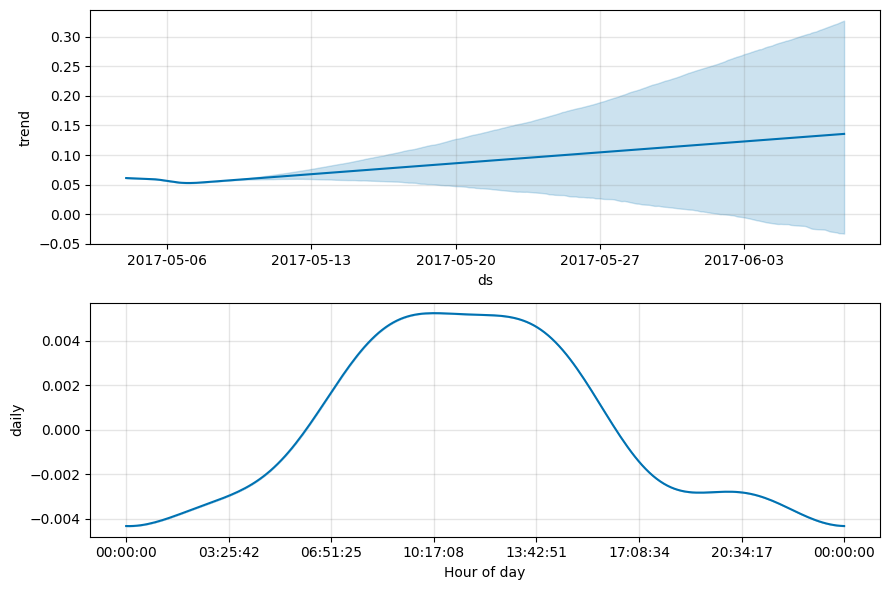

In [ ]:

import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

# data pre-processing
df_prophet = df_hourly.reset_index()[['datetime', 'price']]
df_prophet.rename(columns={'datetime':'ds', 'price':'y'}, inplace=True)

# Remove timezone
df_prophet['ds'] = df_prophet['ds'].dt.tz_localize(None)

# model
model = Prophet(daily_seasonality=True, weekly_seasonality=False, yearly_seasonality=False)
model.fit(df_prophet)

# 30 days forecast
future = model.make_future_dataframe(periods=30*24, freq='H')
forecast = model.predict(future)

# plot
fig = model.plot(forecast)
plt.title("Prophet Forecast - r3.xlarge Linux/UNIX (EU Ireland)")
plt.xlabel("Datetime")
plt.ylabel("Price (USD/hour)")
plt.show()

# plot 2
fig2 = model.plot_components(forecast)
plt.show()


## ROI

**ROI STORICO**

Cerca il prezzo on-demand attuale qui: https://aws.amazon.com/it/ec2/pricing/on-demand/

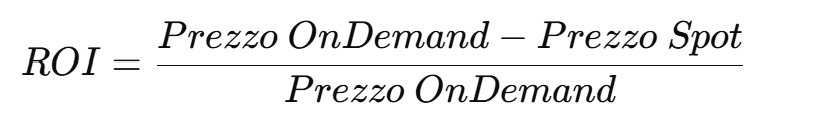

In [ ]:
on_demand_price = 0.3

In [ ]:
ROI_historical = (on_demand_price - df_hourly.mean())/on_demand_price
print(ROI_historical)

0.8113745756783629


**ROI CON PROPHET**

In [ ]:
# Prezzo medio previsto Prophet (ultime 720 ore)
spot_mean_prophet = forecast['yhat'].values[-30*24:].mean()

#ROI
roi_prophet = (on_demand_price - spot_mean_prophet)/on_demand_price
print(roi_prophet)


0.6787701305391026


**ROI CON ARIMA**

In [ ]:
# Calcolo prezzo medio previsto ARIMA (720 ore)
forecast_arima = model_fit.forecast(steps=30*24)
spot_mean_arima = forecast_arima.mean()

# ROI
roi_arima = (on_demand_price - spot_mean_arima)/on_demand_price
print(roi_arima)

0.8113196380081582
